Setup, W&B & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.datasets import load_breast_cancer
import wandb

# Inisialisasi W&B
run = wandb.init(project="breast-cancer-classification", name="logistic-regression-baseline")

# Load dataset langsung dari Scikit-Learn (Dijamin 100% selalu bisa diakses)
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target # 0: Malignant (Ganas), 1: Benign (Jinak)

# Log raw data ke W&B Table
wandb.log({"raw_data": wandb.Table(dataframe=df.head(100))})
print("Dataset Shape:", df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sitiyolandahareniza (sitiyolandahareniza-stikomelrahma) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Cek Keseimbangan Kelas & Split Data

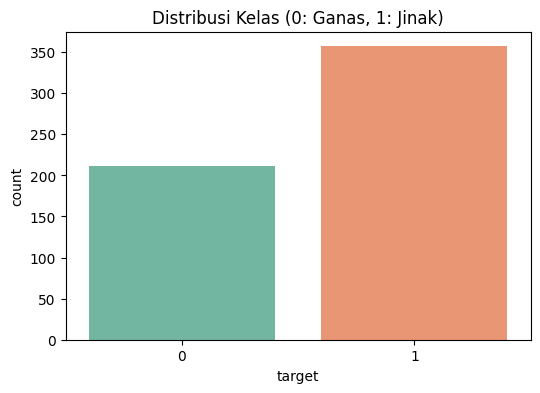

In [2]:
# Cek proporsi target (Penting dalam klasifikasi!)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', hue='target', palette='Set2', legend=False)
plt.title("Distribusi Kelas (0: Ganas, 1: Jinak)")
plt.show()

# Pisahkan Fitur dan Target
X = df.drop(columns=['target'])
y = df['target']

# Split Data: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
wandb.config.update({"test_size": 0.3, "random_state": 42})

Training Model

In [3]:
# Inisialisasi model Logistic Regression
# Parameter max_iter dinaikkan untuk mencegah ConvergenceWarning (Best Practice Profesional)
model = LogisticRegression(max_iter=10000)

# Proses Belajar
model.fit(X_train, y_train)
print("Training selesai!")

Training selesai!


Prediksi & Evaluasi Metrik

In [4]:
# Lakukan prediksi pada data Test
y_pred = model.predict(X_test)

# Hitung Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Log ke W&B
wandb.log({
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1_Score": f1
})

print("--- Hasil Evaluasi Model ---")
print(f"Accuracy : {acc:.4f} (Persentase tebakan benar secara keseluruhan)")
print(f"Precision: {prec:.4f} (Bila model menebak 'Jinak', seberapa akurat tebakannya?)")
print(f"Recall   : {rec:.4f} (Dari semua kasus 'Jinak' asli, berapa persen yang berhasil ditebak model?)")
print(f"F1-Score : {f1:.4f} (Nilai harmonis antara Precision dan Recall)")

--- Hasil Evaluasi Model ---
Accuracy : 0.9766 (Persentase tebakan benar secara keseluruhan)
Precision: 0.9815 (Bila model menebak 'Jinak', seberapa akurat tebakannya?)
Recall   : 0.9815 (Dari semua kasus 'Jinak' asli, berapa persen yang berhasil ditebak model?)
F1-Score : 0.9815 (Nilai harmonis antara Precision dan Recall)


Confusion Matrix Visualization

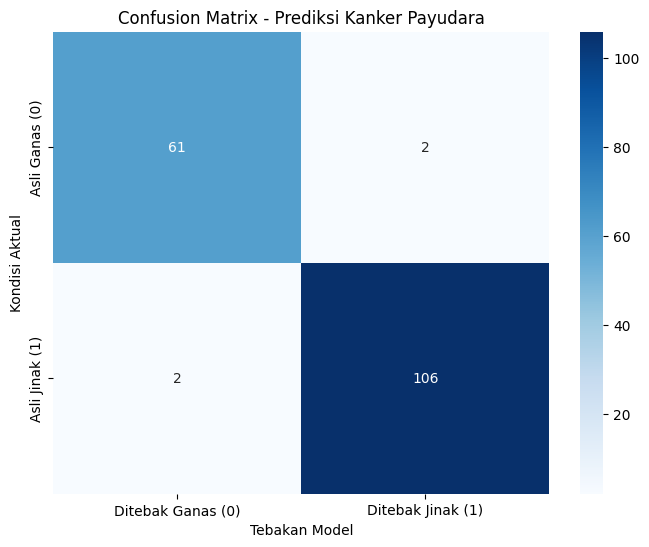


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



Accuracy,▁
F1_Score,▁
Precision,▁
Recall,▁
Accuracy,0.97661
F1_Score,0.98148
Precision,0.98148
Recall,0.98148


In [5]:
# Memvisualisasikan di mana letak kesalahan tebakan model
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ditebak Ganas (0)', 'Ditebak Jinak (1)'],
            yticklabels=['Asli Ganas (0)', 'Asli Jinak (1)'])
plt.title('Confusion Matrix - Prediksi Kanker Payudara')
plt.ylabel('Kondisi Aktual')
plt.xlabel('Tebakan Model')
plt.show()

# Menampilkan Laporan Lengkap
print("\nClassification Report:\n", classification_report(y_test, y_pred))

wandb.finish()